/usr/local/lib/python3.12/dist-packages/albumentations/check_version.py:147: UserWarning: Error fetching version info <urlopen error [Errno -3] Temporary failure in name resolution>
  data = fetch_version_info()


Device : cuda
category
benign       437
malignant    210
normal       133
Name: count, dtype: int64
Total: 780



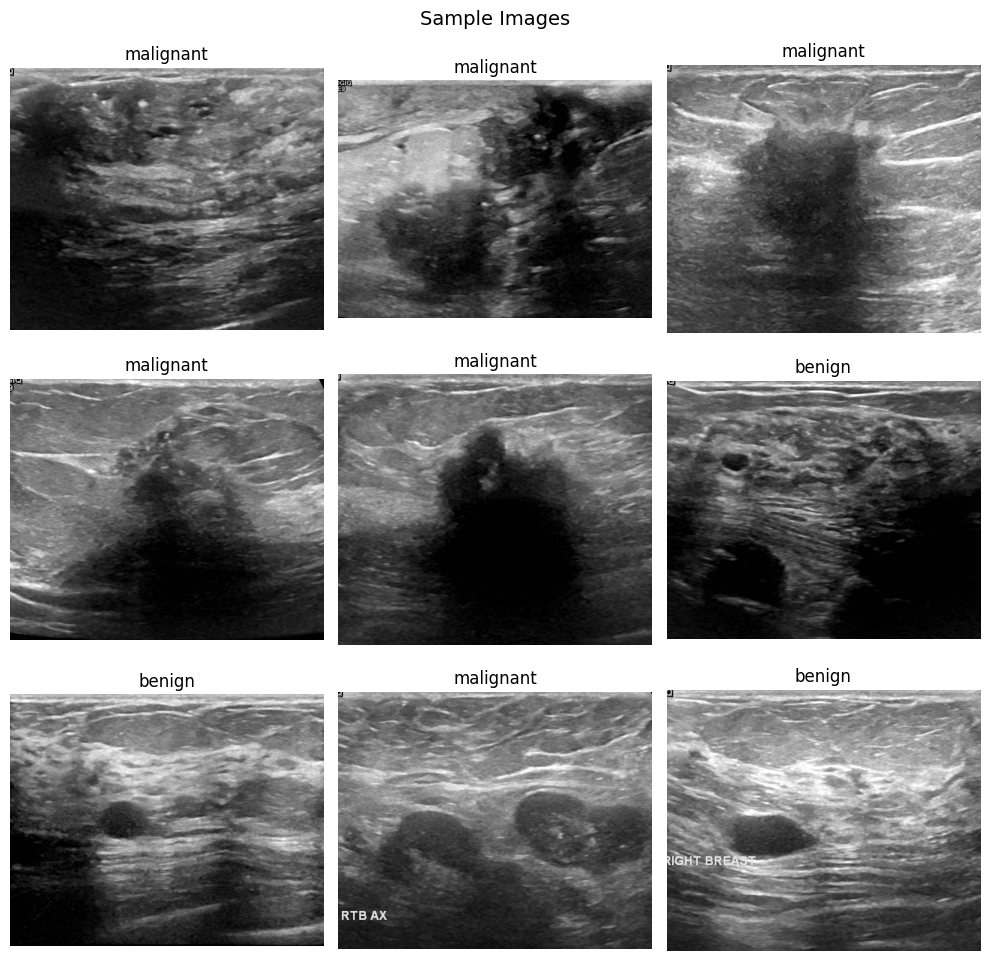

Train 624 | Val 78 | Test 78
Parameters: 52,475,843

Starting training...



Ep  1/20 | Loss 2.1864/1.1248 | Acc  0.4327/0.5513  ✓ saved


Ep  2/20 | Loss 2.1157/1.6347 | Acc  0.4503/0.1795


Ep  3/20 | Loss 2.8486/1.7668 | Acc  0.4279/0.4359


Ep  4/20 | Loss 2.8252/1.5919 | Acc  0.4503/0.5513


...

Ep 16/20 | Loss 0.9956/0.9592 | Acc  0.5593/0.5513


Ep 17/20 | Loss 0.9761/0.9672 | Acc  0.5609/0.5513


Ep 18/20 | Loss 0.9697/0.9576 | Acc  0.5609/0.5513


Ep 19/20 | Loss 0.9808/0.9527 | Acc  0.5609/0.5513  ✓ saved


Ep 20/20 | Loss 0.9725/0.9513 | Acc  0.5577/0.5513  ✓ saved


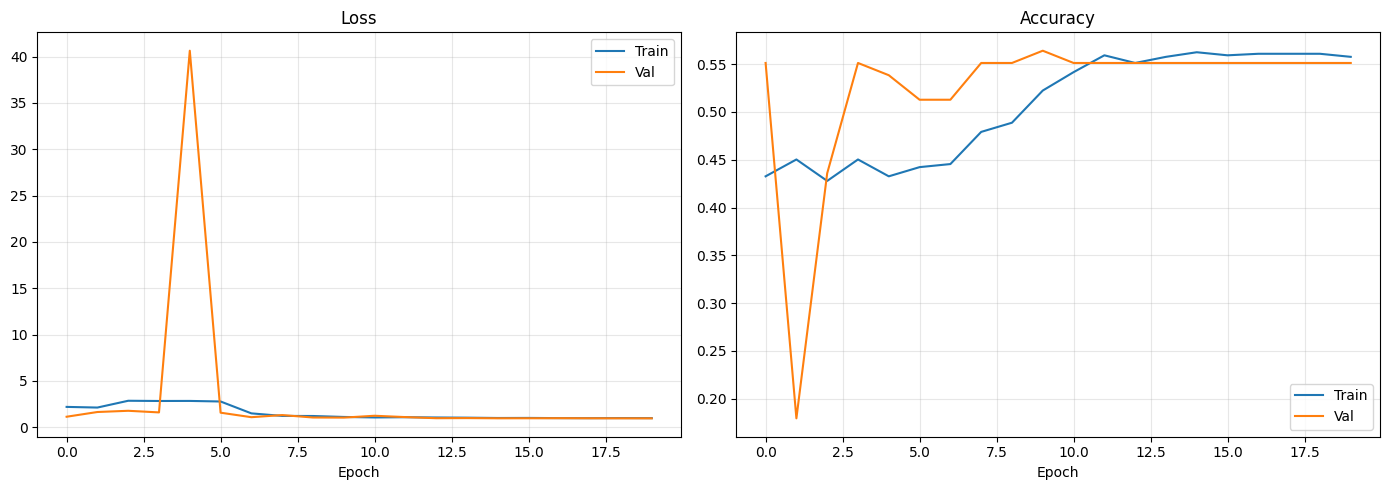


              precision    recall  f1-score   support

      benign       0.56      1.00      0.72        44
   malignant       0.00      0.00      0.00        21
      normal       0.00      0.00      0.00        13

    accuracy                           0.56        78
   macro avg       0.19      0.33      0.24        78
weighted avg       0.32      0.56      0.41        78




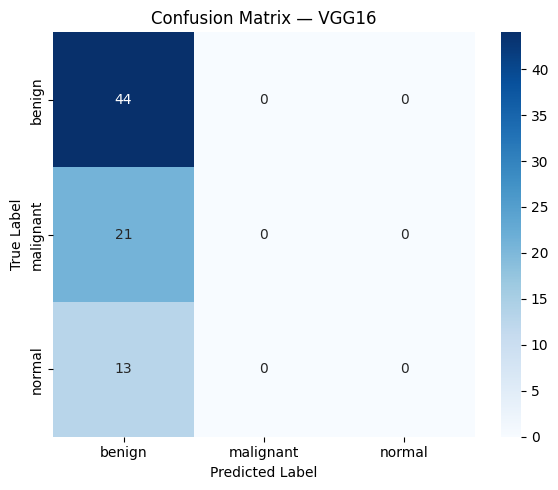

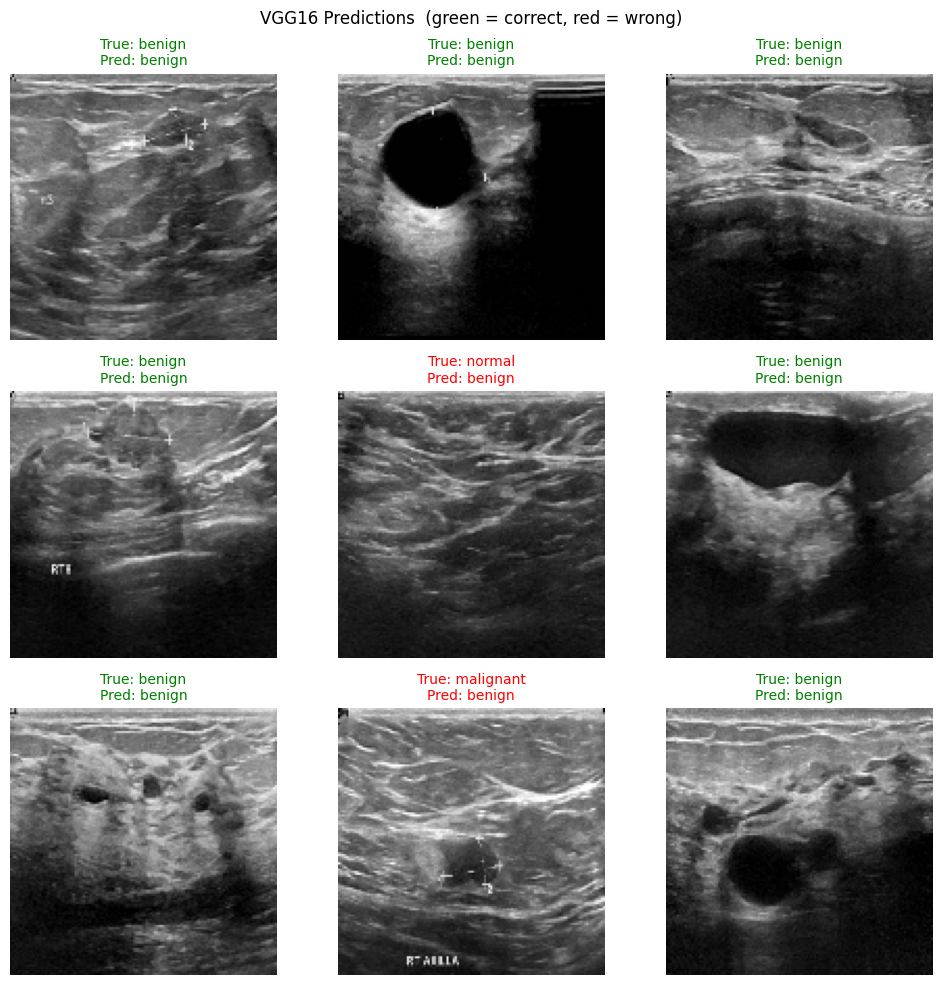


Done!  Best model saved → best_vgg16.pth


In [1]:
# ================================================================
# Breast Ultrasound — Classification with VGG16 (from scratch)
# No internet / no pretrained weights needed
# Classes : benign / malignant / normal
# ================================================================

import os
import cv2
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
from tqdm import tqdm

warnings.filterwarnings("ignore")

# ── CONFIG ───────────────────────────────────────────────────
class CFG:
    DATA_DIR    = "/kaggle/input/datasets/sabahesaraki/breast-ultrasound-images-dataset/Dataset_BUSI_with_GT"
    CATEGORIES  = ["benign", "malignant", "normal"]
    NUM_CLASSES = 3
    IMG_SIZE    = 128       # 224 is too slow on CPU; 128 works fine
    BATCH_SIZE  = 16
    EPOCHS      = 20
    LR          = 1e-3
    SEED        = 42
    DEVICE      = "cuda" if torch.cuda.is_available() else "cpu"
    NUM_WORKERS = 0
    PIN_MEMORY  = torch.cuda.is_available()

random.seed(CFG.SEED)
np.random.seed(CFG.SEED)
torch.manual_seed(CFG.SEED)
if CFG.DEVICE == "cuda":
    torch.cuda.manual_seed_all(CFG.SEED)

print(f"Device : {CFG.DEVICE}")

CLASS2IDX = {c: i for i, c in enumerate(CFG.CATEGORIES)}
IDX2CLASS  = {v: k for k, v in CLASS2IDX.items()}


# ── BUILD DATAFRAME ──────────────────────────────────────────
def build_df(data_dir):
    records = []
    for cat in CFG.CATEGORIES:
        cat_path = os.path.join(data_dir, cat)
        if not os.path.exists(cat_path):
            print(f"[WARNING] Not found: {cat_path}")
            continue
        images = sorted([
            f for f in os.listdir(cat_path)
            if f.endswith(".png") and "_mask" not in f
        ])
        for img_name in images:
            records.append(dict(
                category   = cat,
                label      = CLASS2IDX[cat],
                image_path = os.path.join(cat_path, img_name)
            ))
    df = pd.DataFrame(records)
    print(df["category"].value_counts())
    print(f"Total: {len(df)}\n")
    return df

df = build_df(CFG.DATA_DIR)


# ── SAMPLE VISUALISATION ─────────────────────────────────────
def show_samples(df, n=9):
    samples = df.sample(n, random_state=CFG.SEED).reset_index(drop=True)
    fig, axes = plt.subplots(3, 3, figsize=(10, 10))
    for i, ax in enumerate(axes.flat):
        img = cv2.imread(samples.loc[i, "image_path"])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax.imshow(img)
        ax.set_title(samples.loc[i, "category"], fontsize=12)
        ax.axis("off")
    plt.suptitle("Sample Images", fontsize=14)
    plt.tight_layout()
    plt.savefig("samples.png", dpi=80)
    plt.show()

show_samples(df)


# ── DATASET ──────────────────────────────────────────────────
class BUSIDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df        = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = cv2.imread(row["image_path"])
        if img is None:
            raise FileNotFoundError(f"Cannot read: {row['image_path']}")
        img   = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        label = int(row["label"])

        if self.transform:
            img = self.transform(image=img)["image"]

        if not isinstance(img, torch.Tensor):
            img = torch.from_numpy(img.transpose(2, 0, 1)).float()

        return img, torch.tensor(label, dtype=torch.long)


# ── AUGMENTATIONS ────────────────────────────────────────────
NORM = dict(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))

train_tf = A.Compose([
    A.Resize(CFG.IMG_SIZE, CFG.IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.RandomRotate90(p=0.3),
    A.RandomBrightnessContrast(p=0.3),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1,
                       rotate_limit=15, p=0.4),
    A.GaussNoise(p=0.2),
    A.Normalize(**NORM),
    ToTensorV2(),
])

val_tf = A.Compose([
    A.Resize(CFG.IMG_SIZE, CFG.IMG_SIZE),
    A.Normalize(**NORM),
    ToTensorV2(),
])


# ── SPLIT ────────────────────────────────────────────────────
tr_df, val_df = train_test_split(
    df, test_size=0.2, stratify=df["category"], random_state=CFG.SEED
)
val_df, te_df = train_test_split(
    val_df, test_size=0.5, stratify=val_df["category"], random_state=CFG.SEED
)
print(f"Train {len(tr_df)} | Val {len(val_df)} | Test {len(te_df)}")

def make_loader(split_df, tf, shuffle):
    return DataLoader(
        BUSIDataset(split_df, tf),
        batch_size  = CFG.BATCH_SIZE,
        shuffle     = shuffle,
        num_workers = CFG.NUM_WORKERS,
        pin_memory  = CFG.PIN_MEMORY,
    )

train_loader = make_loader(tr_df,  train_tf, shuffle=True)
val_loader   = make_loader(val_df, val_tf,   shuffle=False)
test_loader  = make_loader(te_df,  val_tf,   shuffle=False)


# ── VGG16 ARCHITECTURE (from scratch, no download) ───────────
#
# VGG16 conv block structure:
#   Block 1 : Conv(64)  × 2  → MaxPool
#   Block 2 : Conv(128) × 2  → MaxPool
#   Block 3 : Conv(256) × 3  → MaxPool
#   Block 4 : Conv(512) × 3  → MaxPool
#   Block 5 : Conv(512) × 3  → MaxPool
#   Classifier : FC(4096) → FC(4096) → FC(num_cls)
#
# Adapted for 128×128 input:
#   After 5 MaxPool(2×2): 128 / 2^5 = 4 → feature map = 512×4×4
#   Classifier input = 512 × 4 × 4 = 8192

def vgg_conv_block(in_ch, out_ch, num_convs):
    """Stack of num_convs conv-bn-relu layers followed by MaxPool."""
    layers = []
    for _ in range(num_convs):
        layers += [
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        ]
        in_ch = out_ch
    layers.append(nn.MaxPool2d(kernel_size=2, stride=2))
    return nn.Sequential(*layers)


class VGG16(nn.Module):
    def __init__(self, num_cls=3, img_size=128):
        super().__init__()

        # 5 convolutional blocks — identical structure to original VGG16
        self.features = nn.Sequential(
            vgg_conv_block(3,   64,  2),   # → 64 ×  64
            vgg_conv_block(64,  128, 2),   # → 32 ×  32
            vgg_conv_block(128, 256, 3),   # → 16 ×  16
            vgg_conv_block(256, 512, 3),   # →  8 ×   8
            vgg_conv_block(512, 512, 3),   # →  4 ×   4
        )

        # Compute flattened feature size dynamically
        dummy   = torch.zeros(1, 3, img_size, img_size)
        feat_sz = self.features(dummy).view(1, -1).shape[1]

        # Classifier head (adapted for 3 classes)
        self.classifier = nn.Sequential(
            nn.Linear(feat_sz, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),
            nn.Linear(4096, 1024),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.4),
            nn.Linear(1024, num_cls),
        )

        # Weight initialisation (Xavier uniform — same as original VGG paper)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.xavier_uniform_(m.weight)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)   # flatten
        return self.classifier(x)


model = VGG16(num_cls=CFG.NUM_CLASSES, img_size=CFG.IMG_SIZE).to(CFG.DEVICE)
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

torch.set_num_threads(os.cpu_count() or 4)


# ── LOSS, OPTIMIZER, SCHEDULER ───────────────────────────────
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=CFG.LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr          = CFG.LR,
    steps_per_epoch = len(train_loader),
    epochs          = CFG.EPOCHS,
    pct_start       = 0.3,
)

history  = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val = float("inf")


# ── TRAINING LOOP ────────────────────────────────────────────
print("\nStarting training...\n")

for epoch in range(CFG.EPOCHS):

    # train
    model.train()
    tr_loss, tr_correct, tr_total = 0.0, 0, 0

    for imgs, labels in tqdm(train_loader, leave=False,
                             desc=f"Ep {epoch+1:2d}/{CFG.EPOCHS}"):
        imgs, labels = imgs.to(CFG.DEVICE), labels.to(CFG.DEVICE)

        optimizer.zero_grad(set_to_none=True)
        out  = model(imgs)
        loss = criterion(out, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        tr_loss    += loss.item()
        tr_correct += (out.argmax(1) == labels).sum().item()
        tr_total   += labels.size(0)

    # validate
    model.eval()
    vl_loss, vl_correct, vl_total = 0.0, 0, 0

    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(CFG.DEVICE), labels.to(CFG.DEVICE)
            out  = model(imgs)
            loss = criterion(out, labels)
            vl_loss    += loss.item()
            vl_correct += (out.argmax(1) == labels).sum().item()
            vl_total   += labels.size(0)

    tr_loss /= len(train_loader)
    vl_loss /= len(val_loader)
    tr_acc   = tr_correct / tr_total
    vl_acc   = vl_correct / vl_total

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(vl_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(vl_acc)

    saved = ""
    if vl_loss < best_val:
        best_val = vl_loss
        torch.save(model.state_dict(), "best_vgg16.pth")
        saved = "  ✓ saved"

    print(
        f"Ep {epoch+1:2d}/{CFG.EPOCHS} | "
        f"Loss {tr_loss:.4f}/{vl_loss:.4f} | "
        f"Acc  {tr_acc:.4f}/{vl_acc:.4f}{saved}"
    )


# ── TRAINING CURVES ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history["train_loss"], label="Train")
axes[0].plot(history["val_loss"],   label="Val")
axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history["train_acc"], label="Train")
axes[1].plot(history["val_acc"],   label="Val")
axes[1].set_title("Accuracy"); axes[1].set_xlabel("Epoch")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=80)
plt.show()


# ── TEST EVALUATION ──────────────────────────────────────────
model.load_state_dict(torch.load("best_vgg16.pth", map_location=CFG.DEVICE))
model.eval()

all_preds, all_labels = [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(CFG.DEVICE), labels.to(CFG.DEVICE)
        out = model(imgs)
        all_preds.extend(out.argmax(1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print(f"\n{'='*50}")
print(classification_report(all_labels, all_preds,
                             target_names=CFG.CATEGORIES))
print(f"{'='*50}\n")

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=CFG.CATEGORIES,
            yticklabels=CFG.CATEGORIES,
            cmap="Blues")
plt.title("Confusion Matrix — VGG16")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=80)
plt.show()


# ── QUALITATIVE PREDICTIONS ──────────────────────────────────
def show_predictions(loader, model, n=9):
    model.eval()
    imgs_all, preds_all, labels_all = [], [], []

    with torch.no_grad():
        for imgs, labels in loader:
            out = model(imgs.to(CFG.DEVICE))
            imgs_all.append(imgs)
            preds_all.extend(out.argmax(1).cpu().numpy())
            labels_all.extend(labels.numpy())
            if len(labels_all) >= n:
                break

    imgs_all = torch.cat(imgs_all)[:n]
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    fig, axes = plt.subplots(3, 3, figsize=(10, 10))
    for i, ax in enumerate(axes.flat):
        img      = (imgs_all[i] * std + mean).permute(1, 2, 0).clamp(0, 1).numpy()
        true_cls = IDX2CLASS[int(labels_all[i])]
        pred_cls = IDX2CLASS[int(preds_all[i])]
        color    = "green" if true_cls == pred_cls else "red"
        ax.imshow(img)
        ax.set_title(f"True: {true_cls}\nPred: {pred_cls}", color=color, fontsize=10)
        ax.axis("off")

    plt.suptitle("VGG16 Predictions  (green = correct, red = wrong)", fontsize=12)
    plt.tight_layout()
    plt.savefig("predictions.png", dpi=80)
    plt.show()

show_predictions(test_loader, model, n=9)
print("\nDone!  Best model saved → best_vgg16.pth")